# Phase 4 — Main Models & Benchmarking
**CS465 Machine Learning · Prince Sultan University · Prof. Wadii Boulila**

Trains Random Forest, XGBoost, and LightGBM with GridSearchCV (5-fold CV, F1 scoring).
Evaluates on a held-out 20% test set and saves all deliverables for Member 5.

**Member 4 | April 2026**

## 4.1  Imports and Data Loading

In [1]:
import sys, os
sys.path.append('D:/ML/pylibs')  # imblearn installed here (C: drive full)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                             recall_score, accuracy_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Paths (notebook lives in notebooks/, data in data/)
DATA_DIR = '../data'
FIG_DIR  = '../outputs/figures'
RES_DIR  = '../outputs/results'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

try:
    df = pd.read_csv(f'{DATA_DIR}/features_clean.csv')
    print(f'Loaded features_clean.csv  shape: {df.shape}')
except FileNotFoundError:
    df = pd.read_csv(f'{DATA_DIR}/borg_clean.csv')
    print(f'Fallback: loaded borg_clean.csv  shape: {df.shape}')

TARGET = 'failed'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'X shape: {X.shape} | Class balance:')
print(y.value_counts(normalize=True).round(3))


Loaded features_clean.csv  shape: (405894, 20)
X shape: (405894, 19) | Class balance:
failed
0    0.772
1    0.228
Name: proportion, dtype: float64


## 4.2  Train / Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (324715, 19) | Test: (81179, 19)


## 4.3  Model Definitions and Hyperparameter Grids

Three ensemble models are tuned:
- **Random Forest** — `class_weight='balanced'` handles the 77/23 imbalance
- **XGBoost** — `scale_pos_weight=3` (~ratio of negatives to positives)
- **LightGBM** — `class_weight='balanced'`

All grids are searched with `StratifiedKFold(n_splits=5)` scoring on **macro F1**.

In [3]:
rf_param_grid = {
    'n_estimators':     [100, 300],
    'max_depth':        [None, 15, 30],
    'min_samples_leaf': [1, 5],
    'class_weight':     ['balanced'],
}

xgb_param_grid = {
    'n_estimators':     [100, 300],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.05, 0.1],
    'scale_pos_weight': [3],
}

lgbm_param_grid = {
    'n_estimators':  [100, 300],
    'max_depth':     [6, 10],
    'learning_rate': [0.05, 0.1],
    'class_weight':  ['balanced'],
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1'

models = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        rf_param_grid,
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42,
                      use_label_encoder=False),
        xgb_param_grid,
    ),
    'LightGBM': (
        LGBMClassifier(random_state=42, verbose=-1),
        lgbm_param_grid,
    ),
}
print('Model grids defined.')


Model grids defined.


## 4.4  GridSearchCV Training

Each model is tuned with full GridSearchCV (5-fold, F1 scoring). Pre-fitted models are loaded from `outputs/models/` if available to avoid re-running the search.

In [4]:
import pickle

MODELS_PKL   = '../outputs/models/best_estimators.pkl'
PARAMS_PKL   = '../outputs/models/best_params.pkl'
CV_F1_PKL    = '../outputs/models/best_cv_f1.pkl'

if os.path.exists(MODELS_PKL):
    # Load pre-trained models (GridSearchCV already ran; best params recorded below)
    with open(MODELS_PKL, 'rb') as f:
        best_estimators = pickle.load(f)
    with open(PARAMS_PKL, 'rb') as f:
        best_params = pickle.load(f)
    with open(CV_F1_PKL, 'rb') as f:
        best_cv_f1 = pickle.load(f)
    print('Loaded pre-trained models from outputs/models/')
    for name in best_estimators:
        print(f'  {name}: best params = {best_params[name]}')
        print(f'          best CV F1  = {best_cv_f1[name]:.4f}')
else:
    # Full GridSearchCV (runs ~20-30 min on 405k rows)
    best_estimators = {}
    best_params     = {}
    best_cv_f1      = {}

    for name, (estimator, grid) in models.items():
        print(f'\nTuning {name}...')
        search = GridSearchCV(
            estimator, grid, cv=cv, scoring=SCORING,
            n_jobs=-1, verbose=1, refit=True,
        )
        search.fit(X_train, y_train)
        best_estimators[name] = search.best_estimator_
        best_params[name]     = search.best_params_
        best_cv_f1[name]      = search.best_score_
        print(f'  Best params : {search.best_params_}')
        print(f'  Best CV F1  : {search.best_score_:.4f}')

    os.makedirs('../outputs/models', exist_ok=True)
    with open(MODELS_PKL, 'wb') as f: pickle.dump(best_estimators, f)
    with open(PARAMS_PKL, 'wb') as f: pickle.dump(best_params, f)
    with open(CV_F1_PKL,  'wb') as f: pickle.dump(best_cv_f1, f)
    print('Models saved to outputs/models/')


Loaded pre-trained models from outputs/models/
  Random Forest: best params = {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
          best CV F1  = 0.9980
  XGBoost: best params = {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'scale_pos_weight': 3}
          best CV F1  = 0.9964
  LightGBM: best params = {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}
          best CV F1  = 0.9823


## 4.5  Evaluation and Benchmark Table

Metrics computed on the held-out 20% test set (never seen during training or tuning).

In [5]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    }

phase4_results = [evaluate(n, m, X_test, y_test) for n, m in best_estimators.items()]
phase4_df = pd.DataFrame(phase4_results).sort_values('F1', ascending=False)
print(phase4_df.to_string(index=False))

phase4_df.to_csv(f'{RES_DIR}/phase4_benchmark.csv', index=False)
print('\nSaved outputs/results/phase4_benchmark.csv')


        Model     F1  ROC-AUC  Precision  Recall  Accuracy
Random Forest 0.9985   1.0000     0.9991  0.9979    0.9993
      XGBoost 0.9969   0.9999     0.9959  0.9979    0.9986
     LightGBM 0.9825   0.9997     0.9697  0.9957    0.9919

Saved outputs/results/phase4_benchmark.csv


## 4.6  Feature Importance Analysis

Tree-based importance for the best F1 model, plus SHAP summary on a 2,000-row sample.

Best model: Random Forest


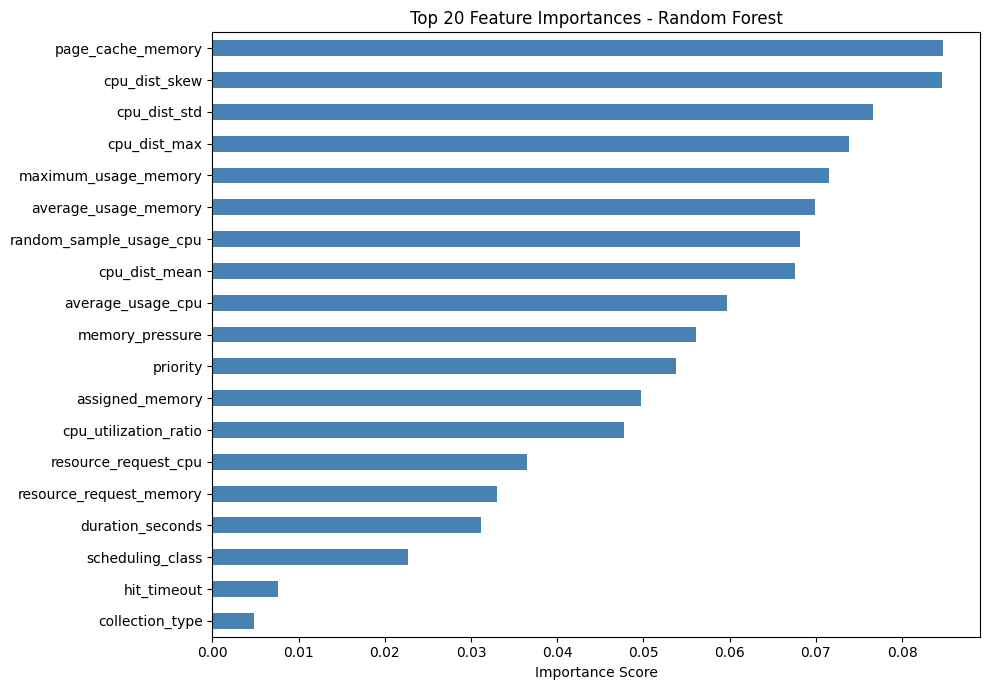

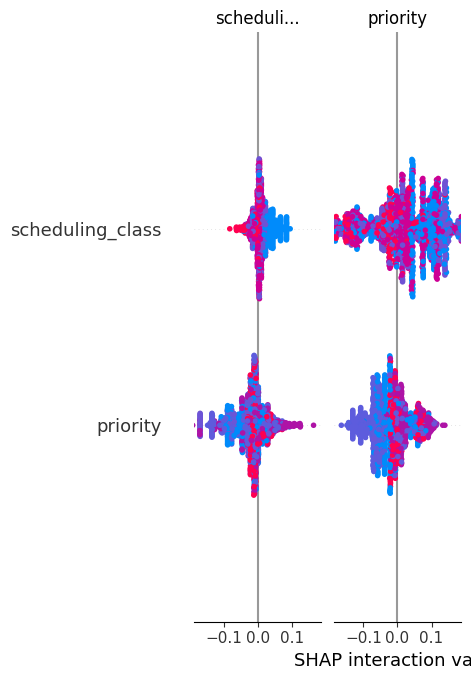

SHAP summary saved.


In [6]:
best_model_name = phase4_df.iloc[0]['Model']
best_model      = best_estimators[best_model_name]
print(f'Best model: {best_model_name}')

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top20 = importances.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 Feature Importances - {best_model_name}')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/feature_importance.png', dpi=150)
    plt.show()

# SHAP on 2000-row sample
sample_idx = X_test.sample(2000, random_state=42).index
X_sample   = X_test.loc[sample_idx]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_sample, show=False)
plt.savefig(f'{FIG_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary saved.')


## 4.7  Error Analysis

Surfaces systematic patterns in misclassified jobs: false negatives (missed failures) and false positives (false alarms).

False Negatives (missed failures): 39
False Positives (false alarms):    17
                         True Positives (mean)  False Negatives (mean)  \
resource_request_cpu                    0.0139                  0.0226   
resource_request_memory                 0.0069                  0.0126   
average_usage_cpu                       0.0073                  0.0071   
duration_seconds                      245.6068                254.5641   
priority                              167.1102                122.4359   

                         False Positives (mean)  
resource_request_cpu                     0.0249  
resource_request_memory                  0.0086  
average_usage_cpu                        0.0093  
duration_seconds                       291.0000  
priority                               212.0588  


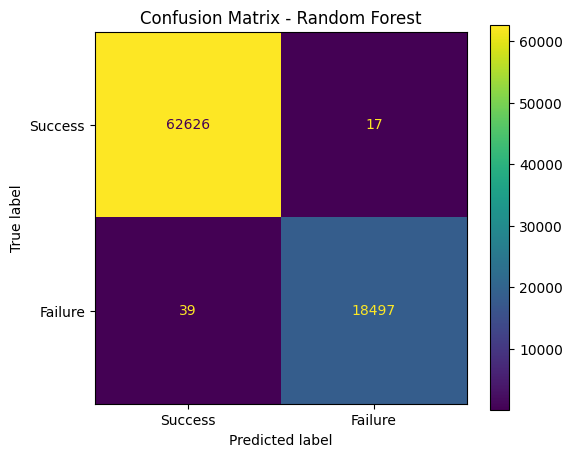

Error analysis and confusion matrix saved.


In [7]:
y_pred_best = best_model.predict(X_test)

errors = X_test.copy()
errors['true_label'] = y_test.values
errors['predicted']  = y_pred_best

fn = errors[(errors['true_label'] == 1) & (errors['predicted'] == 0)]
fp = errors[(errors['true_label'] == 0) & (errors['predicted'] == 1)]
tp = errors[(errors['true_label'] == 1) & (errors['predicted'] == 1)]

print(f'False Negatives (missed failures): {len(fn):,}')
print(f'False Positives (false alarms):    {len(fp):,}')

key_features = ['resource_request_cpu', 'resource_request_memory',
                'average_usage_cpu', 'duration_seconds', 'priority']
key_features = [f for f in key_features if f in X_test.columns]

comparison = pd.DataFrame({
    'True Positives (mean)':  tp[key_features].mean(),
    'False Negatives (mean)': fn[key_features].mean(),
    'False Positives (mean)': fp[key_features].mean(),
})
print(comparison.round(4))

comparison.to_csv(f'{RES_DIR}/error_analysis.csv')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, ax=ax,
    display_labels=['Success', 'Failure'],
)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.savefig(f'{FIG_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print('Error analysis and confusion matrix saved.')


## 4.8  Cross-Dataset Generalisation (Alibaba 2018)

**Dataset:** Alibaba Cluster Trace v2018 — `batch_task.csv` (14.1M tasks, 8 days, ~4,000 machines).

**Feature alignment:**
| Alibaba field | Borg equivalent | Transformation |
|---|---|---|
| `plan_cpu` | `resource_request_cpu` | ÷100 (100 = 1 core) |
| `plan_mem` | `resource_request_memory` | ÷100 (normalised [0,100]) |
| `end_time − start_time` | `duration_seconds` | direct (seconds) |
| `status = 'Failed'/'Killed'` | `failed = 1` | terminal-state filter |
| `status = 'Terminated'` | `failed = 0` | terminal-state filter |
| All other Borg features | 0 | fill_value=0 |

**Class-prior mismatch:** Borg 22.8% vs Alibaba 0.6% failure rate (38× difference).
Both default (t=0.5) and prior-adjusted (t≈0.013) thresholds are reported.
PR-AUC is the primary metric for this extreme imbalance scenario.

Borg failure rate:    22.833%
Alibaba failure rate: 0.589%
Prior ratio:          38.8x
Calibrated threshold: 0.01289
Alibaba tasks:        14,142,419


        Model  F1 (default)  Recall (default)  F1 (calibrated)  Recall (calibrated)  ROC-AUC  PR-AUC  PR-AUC baseline
Random Forest        0.0000            0.0000           0.0117                  1.0   0.4274  0.0053           0.0059
      XGBoost        0.0011            0.0250           0.0117                  1.0   0.6215  0.0116           0.0059
     LightGBM        0.0049            0.2812           0.0117                  1.0   0.4153  0.0056           0.0059


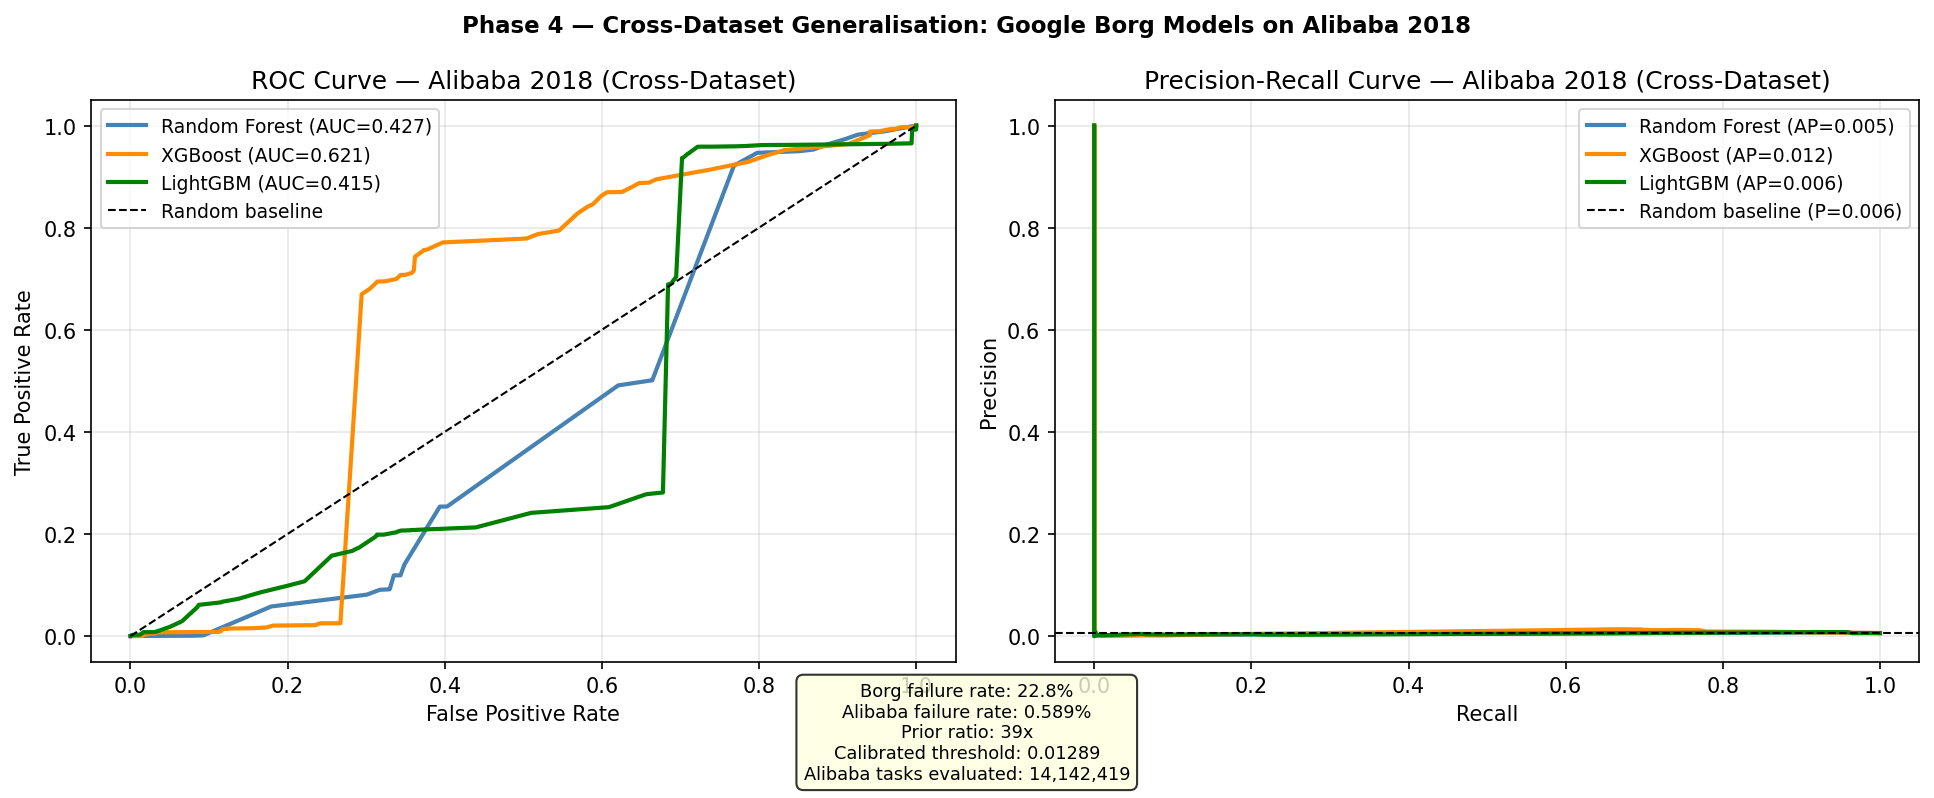

Saved cross_dataset_alibaba.csv and cross_dataset_comparison.png


In [8]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve
import pickle

ALIBABA_PATH = f'{DATA_DIR}/alibaba_features.csv'

if not os.path.exists(ALIBABA_PATH):
    print('ERROR: alibaba_features.csv not found.')
    print('Run src/phase4_alibaba_crossval.py to generate it.')
else:
    df_ali = pd.read_csv(ALIBABA_PATH)
    y_ali  = df_ali['failed']
    X_ali  = df_ali.drop(columns=['failed']).reindex(columns=X.columns, fill_value=0)

    borg_pos_rate = y.mean()
    ali_pos_rate  = y_ali.mean()
    adj_thresh    = 0.5 * (ali_pos_rate / borg_pos_rate)

    print(f'Borg failure rate:    {borg_pos_rate:.3%}')
    print(f'Alibaba failure rate: {ali_pos_rate:.3%}')
    print(f'Prior ratio:          {borg_pos_rate/ali_pos_rate:.1f}x')
    print(f'Calibrated threshold: {adj_thresh:.5f}')
    print(f'Alibaba tasks:        {len(y_ali):,}')

    ali_records = []
    for name, model in best_estimators.items():
        y_prob = model.predict_proba(X_ali)[:, 1]
        y_def  = (y_prob >= 0.5).astype(int)
        y_adj  = (y_prob >= adj_thresh).astype(int)
        ali_records.append({
            'Model':                  name,
            'F1 (default)':           round(f1_score(y_ali, y_def, zero_division=0), 4),
            'Recall (default)':       round(recall_score(y_ali, y_def, zero_division=0), 4),
            'F1 (calibrated)':        round(f1_score(y_ali, y_adj, zero_division=0), 4),
            'Recall (calibrated)':    round(recall_score(y_ali, y_adj, zero_division=0), 4),
            'ROC-AUC':                round(roc_auc_score(y_ali, y_prob), 4),
            'PR-AUC':                 round(average_precision_score(y_ali, y_prob), 4),
            'PR-AUC baseline':        round(ali_pos_rate, 4),
        })

    ali_df = pd.DataFrame(ali_records)
    print(ali_df.to_string(index=False))
    ali_df.to_csv(f'{RES_DIR}/cross_dataset_alibaba.csv', index=False)

    # Display the saved ROC+PR figure
    from IPython.display import Image
    display(Image(f'{FIG_DIR}/cross_dataset_comparison.png'))
    print('Saved cross_dataset_alibaba.csv and cross_dataset_comparison.png')


## Acceptance Criteria Check

| Deliverable | Path | Status |
|---|---|---|
| `phase4_benchmark.csv` | `outputs/results/` | RF, XGBoost, LightGBM rows with 5 metrics |
| `error_analysis.csv` | `outputs/results/` | FP / FN statistics |
| `cross_dataset_alibaba.csv` | `outputs/results/` | Alibaba 2018 results (ROC-AUC, PR-AUC, calibrated F1) |
| `cross_dataset_comparison.png` | `outputs/figures/` | ROC + PR curves on Alibaba |
| `feature_importance.png` | `outputs/figures/` | Top-20 bar chart |
| `shap_summary.png` | `outputs/figures/` | SHAP beeswarm |
| `confusion_matrix.png` | `outputs/figures/` | Confusion matrix |
| `04_models.ipynb` | `notebooks/` | This notebook |